# L1.6 — The fixed-wing kinematics

**Level 1 · Core · 60 minutes**

**Goal.** You can move one fixed-wing for one step, and you know why it is different.

**Check at the end.** You can say what a fixed-wing does at its last waypoint, and why.

> Level 1 uses no simulation loop. You call each module directly.
>
> The text in this course obeys ASD-STE100 Simplified Technical English.

## 1. Three differences from a multirotor

| A multirotor | A fixed-wing |
| --- | --- |
| Moves in any direction at once. | Moves along its nose only. It cannot go sideways. |
| Stops and hovers. | Cannot stop. Its `v_min` is a stall speed. |
| Turns the nose at `yaw_rate_max`. | Turns by banking. The rate is $g\tan\phi / V$, so it depends on the speed. |
| Reaches a bank of 0 always. | Rolls into a bank at `roll_rate_max`, so a turn starts late. |

The model is a coordinated-turn point mass. Lesson L1.3 gives the turn laws. This lesson flies them.

It reads the fixed-wing channels only: `target_course`, `target_airspeed_direction`,
`target_airspeed`, `target_position`, `target_leg_start`, `target_loiter_radius`. It refuses a bare
`target_velocity`. Lesson L1.4 section 5 shows the adapter that converts one into the other.

In [1]:
%matplotlib inline
import dataclasses

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False
BLUE, RED, GREY, GREEN = "#1f77b4", "#d62728", "#7f7f7f", "#2ca02c"

from opencdarr import SMALL_FIXEDWING, MotionCommand, create_aircraft, geo
from opencdarr.kinematics import FixedWing

FW = FixedWing()
PERF = SMALL_FIXEDWING
DT = 0.5
CRUISE = 17.0


def fly(state, command, n: int, dt: float = DT, perf=PERF):
    """Hold one command for n steps. Return every state, the start included."""
    out = [state]
    for _ in range(n):
        out.append(FW.step(out[-1], command, perf, dt))
    return out


def track_xy(states, origin=(52.0, 4.0)) -> np.ndarray:
    return np.array([geo.enu(*origin, s.lat, s.lon) for s in states])


plane = create_aircraft(PERF, id="PLANE", lat=52.0, lon=4.0, trk=0.0, gs=CRUISE)
print(f"envelope: v_min {PERF.v_min:.0f}  v_max {PERF.v_max:.0f} m/s   "
      f"phi_max {PERF.phi_max:.0f} deg   roll_rate_max {PERF.roll_rate_max:.0f} deg/s")

envelope: v_min 12  v_max 25 m/s   phi_max 44 deg   roll_rate_max 60 deg/s


## 2. Fly a course it cannot fly directly

Command the exact opposite course. A multirotor would reverse its velocity in one step, inside `ax`.
A fixed-wing has to turn the whole way round, and the turn costs distance.

Read `bank` at each step. It is a field of the state, not a number the model works out and throws
away.

In [2]:
reversal = fly(plane, MotionCommand(target_course=180.0, target_airspeed=CRUISE), 60)

print(f"{'t [s]':>7}{'trk [deg]':>12}{'bank [deg]':>12}{'gs [m/s]':>11}")
for k in (0, 1, 2, 3, 6, 10, 14, 20, 40, 60):
    s = reversal[k]
    print(f"{k * DT:>7.1f}{s.trk:>12.1f}{s.bank:>12.1f}{s.gs:>11.2f}")

settled = next(k for k, s in enumerate(reversal) if abs(s.trk - 180.0) < 0.5)
print(f"\nit reaches the new course after {settled * DT:.1f} s")

  t [s]   trk [deg]  bank [deg]   gs [m/s]
    0.0         0.0         0.0      17.00
    0.5       350.5       -30.0      17.00
    1.0       334.5       -44.0      17.00
    1.5       318.5       -44.0      17.00
    3.0       270.7       -44.0      17.00
    5.0       206.8       -44.0      17.00
    7.0       181.7        -5.8      17.00
   10.0       180.0        -0.1      17.00
   20.0       180.0        -0.0      17.00
   30.0       180.0        -0.0      17.00

it reaches the new course after 8.0 s


## 3. The roll-in delay

`roll_rate_max` bounds how fast the bank may change. A full-bank turn is not available at once. The
first second of any fixed-wing avoidance is spent rolling, and the aircraft flies almost straight
through it.

In [3]:
t_roll = PERF.phi_max / PERF.roll_rate_max
print(f"{PERF.phi_max:.0f} deg of bank at {PERF.roll_rate_max:.0f} deg/s takes {t_roll:.2f} s")
print(f"at {CRUISE:.0f} m/s that is {CRUISE * t_roll:.0f} m flown before the turn is established\n")

for k in range(5):
    s = reversal[k]
    print(f"  t = {k * DT:>4.1f} s   bank {s.bank:>6.1f} deg   trk {s.trk:>6.1f} deg")

44 deg of bank at 60 deg/s takes 0.73 s
at 17 m/s that is 12 m flown before the turn is established

  t =  0.0 s   bank    0.0 deg   trk    0.0 deg
  t =  0.5 s   bank  -30.0 deg   trk  350.5 deg
  t =  1.0 s   bank  -44.0 deg   trk  334.5 deg
  t =  1.5 s   bank  -44.0 deg   trk  318.5 deg
  t =  2.0 s   bank  -44.0 deg   trk  302.6 deg


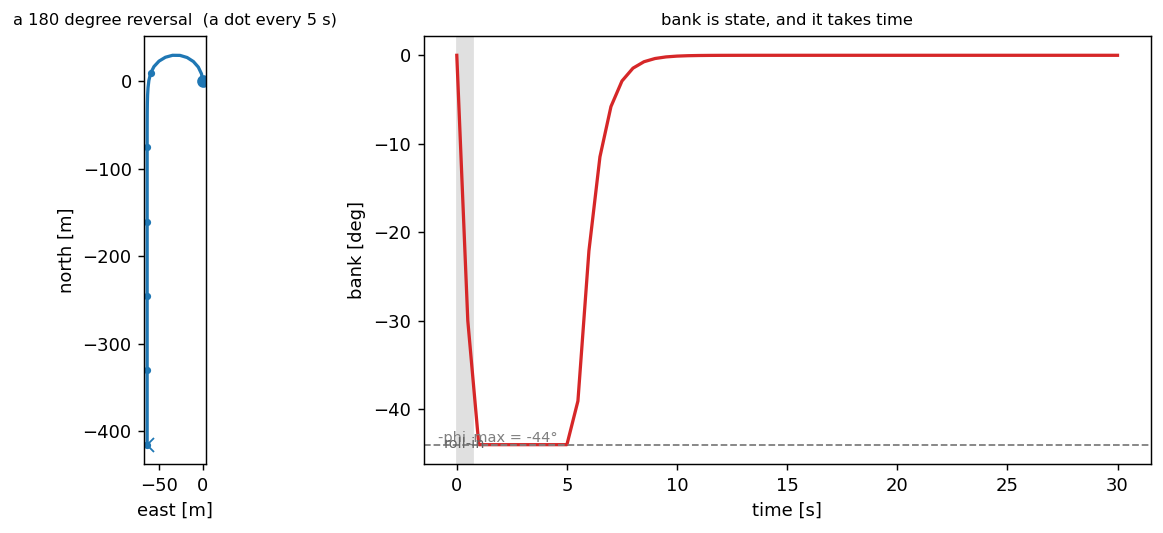

In [4]:
fig, (ax_xy, ax_b) = plt.subplots(1, 2, figsize=(10.6, 4.2))

xy = track_xy(reversal)
ax_xy.plot(xy[:, 0], xy[:, 1], lw=1.8, color=BLUE)
ax_xy.plot(xy[0, 0], xy[0, 1], marker="o", ms=6, color=BLUE)
ax_xy.plot(xy[-1, 0], xy[-1, 1], marker="x", ms=8, color=BLUE)
ax_xy.plot(xy[::10, 0], xy[::10, 1], ls="none", marker="o", ms=3, color=BLUE)
ax_xy.set_aspect("equal")
ax_xy.set_xlabel("east [m]")
ax_xy.set_ylabel("north [m]")
ax_xy.set_title("a 180 degree reversal  (a dot every 5 s)", fontsize=9)

ts = np.arange(len(reversal)) * DT
ax_b.plot(ts, [s.bank for s in reversal], lw=1.8, color=RED, label="bank")
ax_b.axhline(-PERF.phi_max, ls="--", lw=1.0, color=GREY)
ax_b.annotate(f"-phi_max = {-PERF.phi_max:.0f}°", (0.02, -PERF.phi_max),
              xycoords=("axes fraction", "data"), ha="left", va="bottom", fontsize=8, color=GREY)
ax_b.axvspan(0, t_roll, color="0.88", zorder=0)
ax_b.annotate("roll-in", (t_roll / 2, 0.03), xycoords=("data", "axes fraction"), ha="center",
              va="bottom", fontsize=8, color="0.4")
ax_b.set_xlabel("time [s]")
ax_b.set_ylabel("bank [deg]")
ax_b.set_title("bank is state, and it takes time", fontsize=9)
fig.tight_layout()

## 4. The speed that turns tightest is not the slowest

`phi_max` is not the only bank limit. A coordinated turn raises the stall speed by the load factor,
$V_\text{stall}(\phi) = v_\text{stall}\sqrt{1/\cos\phi}$, so the airspeed must stay above it:

$$\cos\phi \ge \left(\frac{v_\text{stall}}{V}\right)^2$$

The model takes the **smaller** of that cap and `phi_max`. Two results follow, and both matter in an
encounter:

- At exactly `v_min` the usable bank is 0. The aircraft cannot turn at all.
- The tightest turn sits at a middle speed, not at the slowest.

Measure it. Hold a hard left turn, take the settled turn rate off the flown track, and get the
radius from $R = V/\dot\psi$. This does not need a complete circle, so it works even when the
aircraft flies almost straight.

In [5]:
from opencdarr.kinematics.fixedwing import _stall_bank_limit

G = 9.80665


def hard_turn(speed: float, n: int = 220):
    """Hold a hard left turn at one airspeed. Return every state."""
    states = [create_aircraft(PERF, id="P", lat=52.0, lon=4.0, trk=0.0, gs=speed)]
    for _ in range(n):
        target = (states[-1].trk - 90.0) % 360.0      # re-command 90 deg left, so the turn stays hard
        states.append(FW.step(states[-1], MotionCommand(target_course=target,
                                                        target_airspeed=speed), PERF, DT))
    return states


def settled_radius(states, speed: float) -> tuple[float, float]:
    """(turn rate [deg/s], radius [m]) from the last 20 steps of a flown turn."""
    trks = np.degrees(np.unwrap(np.radians([s.trk for s in states])))
    rate = abs(np.diff(trks)[-20:].mean()) / DT
    return rate, speed / np.radians(rate) if rate > 1e-6 else float("inf")


SPEEDS = (PERF.v_min, 13.0, CRUISE, PERF.v_max)
tracks, radii = {}, {}
print(f"{'V [m/s]':>9}{'stall cap':>11}{'usable bank':>13}{'rate [deg/s]':>14}"
      f"{'R measured':>13}{'R formula':>12}")
for speed in SPEEDS:
    states = hard_turn(speed)
    tracks[speed] = track_xy(states)
    rate, measured = settled_radius(states, speed)
    bank = abs(states[-1].bank)
    formula = speed ** 2 / (G * np.tan(np.radians(bank))) if bank > 1e-6 else float("inf")
    radii[speed] = measured
    cap = _stall_bank_limit(speed, PERF.v_min, PERF.phi_max)
    print(f"{speed:>9.0f}{cap:>11.1f}{bank:>13.1f}{rate:>14.2f}{measured:>13.1f}{formula:>12.1f}")

  V [m/s]  stall cap  usable bank  rate [deg/s]   R measured   R formula
       12        0.0          0.0          0.00          inf         inf
       13       31.6         31.6         26.55         28.1        28.1
       17       44.0         44.0         31.92         30.5        30.5
       25       44.0         44.0         21.70         66.0        66.0


/var/folders/gt/7bzbbv711312cfd_13h4fkm5z8xgxd/T/ipykernel_71336/3808971011.py:17: RuntimeWarning: divide by zero encountered in divide
  r_curve = np.where(caps > 1e-6, v ** 2 / (G * np.tan(np.radians(caps))), np.nan)


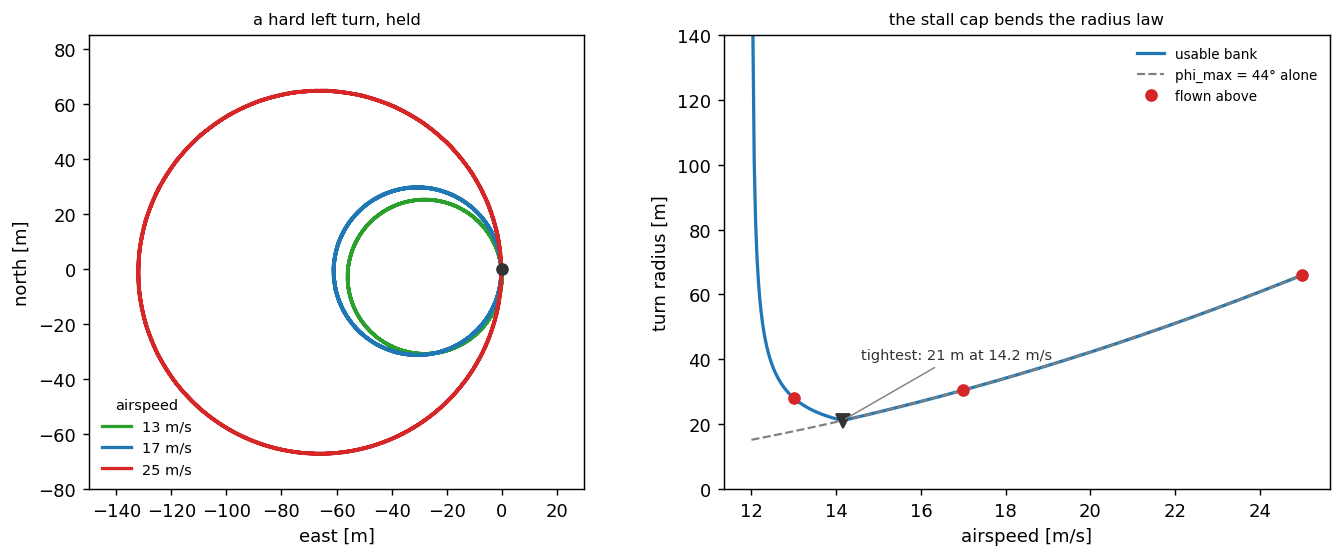

In [6]:
fig, (ax_c, ax_r) = plt.subplots(1, 2, figsize=(10.8, 4.4))

for speed, colour in zip(SPEEDS[1:], (GREEN, BLUE, RED)):     # 12 m/s flies straight, off this scale
    xy = tracks[speed]
    ax_c.plot(xy[:, 0], xy[:, 1], lw=1.8, color=colour, label=f"{speed:.0f} m/s")
ax_c.plot(0, 0, marker="o", ms=6, color="0.2")
ax_c.set_aspect("equal")
ax_c.set_xlim(-150, 30)
ax_c.set_ylim(-80, 85)
ax_c.set_xlabel("east [m]")
ax_c.set_ylabel("north [m]")
ax_c.set_title("a hard left turn, held", fontsize=9)
ax_c.legend(frameon=False, fontsize=8, title="airspeed", title_fontsize=8, loc="lower left")

v = np.linspace(PERF.v_min, PERF.v_max, 400)
caps = np.array([_stall_bank_limit(x, PERF.v_min, PERF.phi_max) for x in v])
r_curve = np.where(caps > 1e-6, v ** 2 / (G * np.tan(np.radians(caps))), np.nan)
ax_r.plot(v, r_curve, lw=1.8, color=BLUE, label="usable bank")
ax_r.plot(v, v ** 2 / (G * np.tan(np.radians(PERF.phi_max))), lw=1.2, ls="--", color=GREY,
          label=f"phi_max = {PERF.phi_max:.0f}° alone")
finite = [(s, radii[s]) for s in SPEEDS if np.isfinite(radii[s])]
ax_r.plot([s for s, _ in finite], [r for _, r in finite], ls="none", marker="o", ms=6, color=RED,
          label="flown above")
best = int(np.nanargmin(r_curve))
ax_r.plot(v[best], r_curve[best], marker="v", ms=8, color="0.2")
ax_r.annotate(f"tightest: {r_curve[best]:.0f} m at {v[best]:.1f} m/s", (v[best], r_curve[best]),
              (10, 34), textcoords="offset points", fontsize=8, color="0.2",
              arrowprops=dict(arrowstyle="-", color="0.5", lw=0.8))
ax_r.set_ylim(0, 140)
ax_r.set_xlabel("airspeed [m/s]")
ax_r.set_ylabel("turn radius [m]")
ax_r.set_title("the stall cap bends the radius law", fontsize=9)
ax_r.legend(frameon=False, fontsize=7.5)
fig.tight_layout()

## 5. Follow a leg, not a point

Two ways to reach a waypoint, and they are different flight:

- **Pure pursuit** — give `target_position` alone. The aircraft aims at the point. It reaches the
  point, but it does not care where it flies on the way.
- **Leg tracking** — give `target_position` **and** `target_leg_start`. The two make a **line**, and
  the L1 tracker nulls the cross-track distance to that line.

Give both whenever the path matters. A mission autopilot does it for you. Lesson L1.7 shows that.

Start the aircraft 200 m off the line and watch the cross-track distance.

In [7]:
LEG_START = (52.0, 4.0)
LEG_END = geo.forward(52.0, 4.0, 90.0, 2000.0)         # 2 km to the east

offset_lat, _ = geo.forward(52.0, 4.0, 0.0, 200.0)      # start 200 m north of the line
off_line = create_aircraft(PERF, id="P", lat=offset_lat, lon=4.0, trk=90.0, gs=CRUISE)

runs = {
    "pure pursuit": MotionCommand(target_position=LEG_END, target_airspeed=CRUISE),
    "leg tracking": MotionCommand(target_position=LEG_END, target_leg_start=LEG_START,
                                  target_airspeed=CRUISE),
}
paths = {name: track_xy(fly(off_line, cmd, 160)) for name, cmd in runs.items()}

print(f"{'':<16}{'cross-track at 500 m':>22}{'at 1000 m':>13}{'at the end':>13}")
for name, xy in paths.items():
    at = lambda east: xy[np.argmin(np.abs(xy[:, 0] - east)), 1]
    print(f"{name:<16}{at(500.0):>22.1f}{at(1000.0):>13.1f}{xy[-1, 1]:>13.1f}")

                  cross-track at 500 m    at 1000 m   at the end
pure pursuit                     150.7        100.6         65.0
leg tracking                       0.0          0.0          0.0


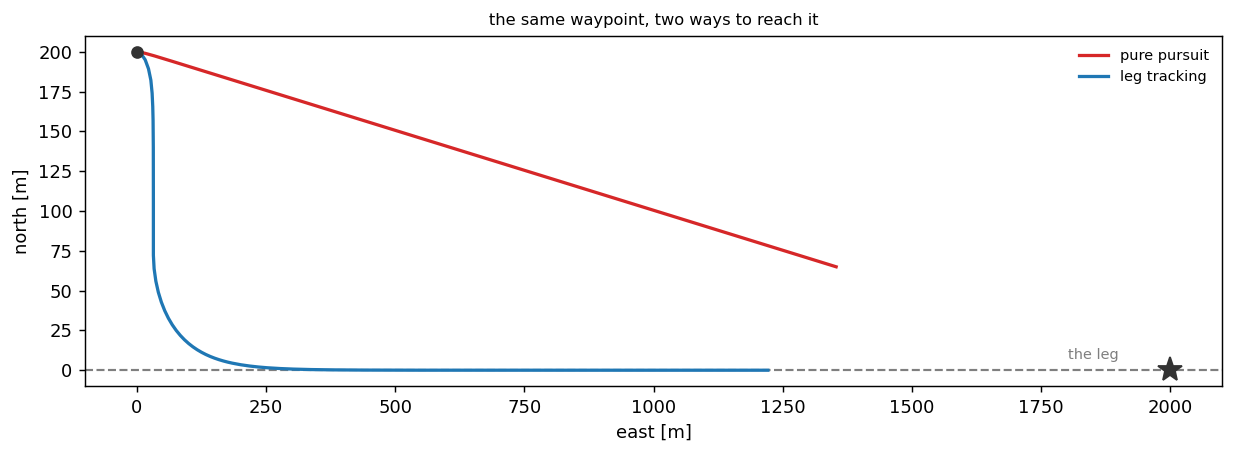

In [8]:
fig, ax = plt.subplots(figsize=(9.6, 3.6))
ax.axhline(0.0, lw=1.2, color=GREY, ls="--")
ax.annotate("the leg", (1900, 0), (0, 6), textcoords="offset points", fontsize=8, color=GREY,
            ha="right")
for (name, xy), colour in zip(paths.items(), (RED, BLUE)):
    ax.plot(xy[:, 0], xy[:, 1], lw=1.8, color=colour, label=name)
ax.plot(0, 200, marker="o", ms=6, color="0.2")
ax.plot(*geo.enu(52.0, 4.0, *LEG_END), marker="*", ms=14, color="0.2")
ax.set_xlabel("east [m]")
ax.set_ylabel("north [m]")
ax.set_title("the same waypoint, two ways to reach it", fontsize=9)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

## 6. It cannot stop, so it orbits

At its last waypoint a multirotor hovers. A fixed-wing cannot: below `v_min` it stalls. So it flies
a circle around the point at `target_loiter_radius`.

This has a consequence for Level 2. A run that stops when every aircraft is "within `stop_within`
metres of its final waypoint" will never stop for a fixed-wing if `stop_within` is smaller than the
loiter radius. Give at least the loiter radius, and the default is 80 m.

commanded loiter radius   80 m
held over the last 30 s   min 81.0 m   max 81.0 m

so a stop_within below 80 m would never trigger for this aircraft


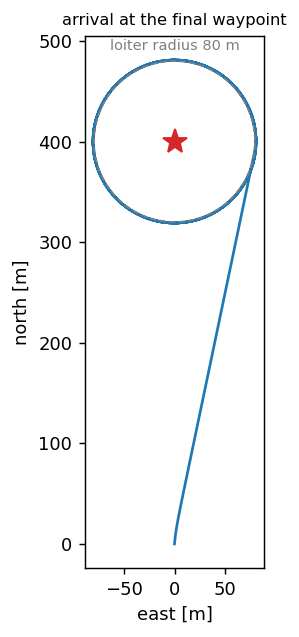

In [9]:
CENTRE = geo.forward(52.0, 4.0, 0.0, 400.0)            # 400 m to the north
RADIUS = 80.0

orbit = fly(plane, MotionCommand(target_position=CENTRE, target_loiter_radius=RADIUS,
                                 target_airspeed=CRUISE), 300)
rel = np.array([geo.enu(*CENTRE, s.lat, s.lon) for s in orbit])
ranges = np.hypot(rel[:, 0], rel[:, 1])

print(f"commanded loiter radius   {RADIUS:.0f} m")
print(f"held over the last 30 s   min {ranges[-60:].min():.1f} m   max {ranges[-60:].max():.1f} m")
print(f"\nso a stop_within below {RADIUS:.0f} m would never trigger for this aircraft")

fig, ax = plt.subplots(figsize=(5.2, 5.0))
xy = track_xy(orbit)
c_xy = geo.enu(52.0, 4.0, *CENTRE)
ax.plot(xy[:, 0], xy[:, 1], lw=1.5, color=BLUE)
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(c_xy[0] + RADIUS * np.cos(theta), c_xy[1] + RADIUS * np.sin(theta), ls="--", lw=1.0,
        color=GREY)
ax.plot(*c_xy, marker="*", ms=14, color=RED)
ax.annotate(f"loiter radius {RADIUS:.0f} m", (c_xy[0], c_xy[1] + RADIUS), (0, 6),
            textcoords="offset points", ha="center", fontsize=8, color=GREY)
ax.set_aspect("equal")
ax.set_xlabel("east [m]")
ax.set_ylabel("north [m]")
ax.set_title("arrival at the final waypoint", fontsize=9)
fig.tight_layout()

## Do it yourself

1. Halve `roll_rate_max` with `dataclasses.replace`. Run section 2 again and compare the time to
   reach the new course.
2. Command `target_airspeed=8.0` in section 2. The stall floor raises it. Find the flown speed.
3. Start the aircraft 600 m off the leg in section 5. Find where the two paths meet.
4. Set `target_loiter_radius=200.0` in section 6. Check the held radius.

## Check

1. What does a fixed-wing do at its last waypoint, and why?
2. Two aircraft at the same bank fly different circles. What makes them different? At which speed
   does this airframe turn tightest, and why is it not the slowest?
3. Why is `bank` a field of `AircraftState` and not a value the model works out each step?

## Next

`L1.7 — The autopilot and the mission`. You can fly both airframes by hand. Next one autopilot flies
both from the same plan.